# Práctica NPL por Blanca Martín Muñoz.

En la práctica de NPL, tenemos como objetivo hacer un analisis de sentimiento frente a cualquier dataset de reviews evaluados en un rango de 5 entrellas en Amazon. En nuestro caso, utilizaremos un dataset sobre críticas hacia libros, queriendo trabajar con un subconjunto de 5000 muestras donde las clases (calificaciones/clasificaciones) estén balanceadas. Esto se propone en clase para facilitar el desempeño de la práctica al requerir menos capacidad de procesamiento, asi como menos problemas a la hora de encontrar un modelo con mejores prestaciones.

Como se ha indicado en el enunciado de la práctica, esta se dividirá en 4 notebooks, teniendo cada uno de ellos un objetivo concreto según el pipeline propio de cualquier tipo de proyecto NPL. Esto es:

1. Descarga de datos y exploración de estos.
2. Preprocesamiento de texto
3. Entrenamiento y testeo de un modelo de analísis de sentimiento.
4. Reporte de métrica y conclusiones.

Por el título de este notebook, podemos ver que nos encontramos en el paso 1 de este proceso. Por tanto:

# 1. Descarga de datos:

Como ya se ha indicado, haremos una descarga de reviews de amazon sobre libros que está calificada según el número de estrellas (de 1 a 5). De esta dataset se tomarán solo 5000 muestras y se intentará que las muestras estén balanceadas según la clase.


In [3]:
# Nos descargamos el dataset de reviews sobre libros de Amazon gracias a (se cita como se indica en la web):
"""@article{hou2024bridging,
  title={Bridging Language and Items for Retrieval and Recommendation},
  author={Hou, Yupeng and Li, Jiacheng and He, Zhankui and Yan, An and Chen, Xiusi and McAuley, Julian},
  journal={arXiv preprint arXiv:2403.03952},
  year={2024}
}"""

'@article{hou2024bridging,\n  title={Bridging Language and Items for Retrieval and Recommendation},\n  author={Hou, Yupeng and Li, Jiacheng and He, Zhankui and Yan, An and Chen, Xiusi and McAuley, Julian},\n  journal={arXiv preprint arXiv:2403.03952},\n  year={2024}\n}'

In [1]:
# Para que no se me descargue cada vez que abro el collab:

"""from google.colab import drive
import os
drive.mount('/content/drive')

! mkdir -p /content/drive/MyDrive/practica_NPL
! cd /content/drive/MyDrive/practica_NPL

path = "/content/drive/MyDrive/practica_NPL"

if not os.path.exists(path):
    !wget https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories/Books.jsonl.gz
    !gunzip Books.jsonl.gz"""

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!wget https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories/Books.jsonl.gz

--2026-02-07 17:16:53--  https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories/Books.jsonl.gz
Resolving mcauleylab.ucsd.edu (mcauleylab.ucsd.edu)... 137.110.161.5
Connecting to mcauleylab.ucsd.edu (mcauleylab.ucsd.edu)|137.110.161.5|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6216820644 (5.8G) [application/gzip]
Saving to: ‘Books.jsonl.gz’

Books.jsonl.gz      100%[===================>]   5.79G  19.6MB/s    in 5m 11s  

2026-02-07 17:22:05 (19.1 MB/s) - ‘Books.jsonl.gz’ saved [6216820644/6216820644]



In [3]:
!gunzip Books.jsonl.gz

In [27]:
# Como indicado en la pagina web:
import json
import pandas as pd
import os

os.listdir("/content")
ruta = "/content/Books.jsonl.gz"

data_books_json = []

file = "Books.jsonl"
max_reviews = 50000 # e.g., "All_Beauty.jsonl", downloaded from the `review` link above
with open(file, 'r') as fp:
    for i, line in enumerate(fp):
        if i >= max_reviews:
            break
        data_books_json.append(json.loads(line))

data_books_df= pd.DataFrame(data_books_json)

Investigamos nuestro dataframe sobre reviews de libros:

In [28]:
print(data_books_df.head(5))

   rating                                              title  \
0     1.0      Not a watercolor book! Seems like copies imo.   
1     5.0  Updated: after 1st arrived damaged this one is...   
2     5.0                              Excellent! I love it!   
3     5.0       Updated after 1st arrived damaged. Excellent   
4     5.0                                Beautiful patterns!   

                                                text  \
0  It is definitely not a watercolor book.  The p...   
1  Updated: after first book arrived very damaged...   
2  I bought it for the bag on the front so it pai...   
3  Updated: after 1st arrived damaged the replace...   
4  I love this book!  The patterns are lovely. I ...   

                                              images        asin parent_asin  \
0  [{'small_image_url': 'https://m.media-amazon.c...  B09BGPFTDB  B09BGPFTDB   
1                                                 []  0593235657  0593235657   
2                                     

In [29]:
data_books_df.shape

(50000, 10)

In [30]:
data_books_df.columns

Index(['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id',
       'timestamp', 'helpful_vote', 'verified_purchase'],
      dtype='object')

Como podemos ver, aunque no estaba indicado como ponía en el enuciado de la práctica con el "5-core", podemos ver en la página web que la columna **"rating"** es aquella con la valoración final del libro, con valores entre 1.0 y el 5.0. También se obeserva que en la columna **"text"** se encuentra la descripción más detallada sobre la crítica frente a ese productor. Por tanto, nos quedamos con esas dos columnas dentro del dataset ya que la primera será la predicción/label, y la otra será la que nos ayude a extraer las caracteristiras/features/variables.

Asimismo, para empezar este preprocesamiento, nos quedaremos con filas que no tengan niguno de estos valores como nulos. Además, tendremos que clasificar las labels según el sentimiento entre positivas y negativas. Para ello, según como hemos hecho en clase, las críticas con una puntacion mayor o igual a 3 estrellas se considerarán como positivas, mientras que menor a 3, serán negativas. De esta manera, se reduce el problema a una clasificación binaria.

In [32]:
data_books_df = data_books_df [["rating", "text"]]
data_books_df= data_books_df.dropna()

In [33]:
data_books_df.head(3)

,rating,text
0,1.0,It is definitely not a watercolor book. The p...
1,5.0,Updated: after first book arrived very damaged...
2,5.0,I bought it for the bag on the front so it pai...


In [34]:
# Para comprobar que es valor numerico y puede hacer las condiciones en base a numeros posteriormente
data_books_df["rating"].dtype

dtype('float64')

In [35]:
# Como visto en clase

def label_sentiment(ranking_fila):
    if ranking_fila < 3:
        return 0
    else:
        return 1

data_books_df['sentiment'] = data_books_df['rating'].apply(label_sentiment)

data_books_df['sentiment'].value_counts()

,count
sentiment,
1,46780
0,3220


In [36]:
data_books_df['rating'].value_counts()

,count
rating,
5.0,32092
4.0,10225
3.0,4463
2.0,1774
1.0,1446


# 2. Estudio exploratorio de los datos:

## 2.1. Preparación del corpus

Existe un paso más en la preparación delcorpus con el quevamos a trabajar:
Como se puede ver, existe un desbalanceo de opiniones/sentimiento/clases en mi dataset, lo cual se podría esperar al unir 3 rankings en una clase, y tan solo 2 en otra. Aun así, teniendo en cuenta la clasificación inicial, son minoria las reviews negativas. Este desbalanceo, como ya hemos visto en módulos anteriores, supone un problema para que el modelo aprenda y pueda generalizar, ya que tiende a estar sesgado a las clases mayoritarias. Es por ello que, como hemos mencionado al principio y se ha visto en clase, se hará una selección de este dataset inicial a un dataset con las clases balanceadas para facilitarnos la tarea. Del mismo modo, por tema de memoria, como comentamos también en clase, se hará uso de tan solo 5000 muestras que, aunque pueda ser un número pequeño para que el modelo tenga buenas prestaciones, como el objetivo no es sacar 'buenas' métricas, se prioriza el rendimiento del código.

Para ver de fomra más visual como se compone el dataset orginal:

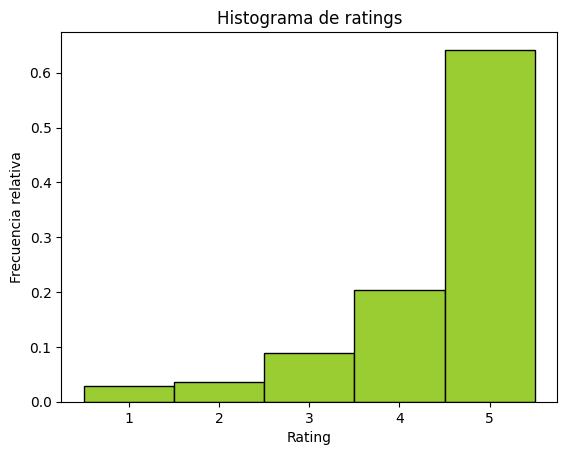

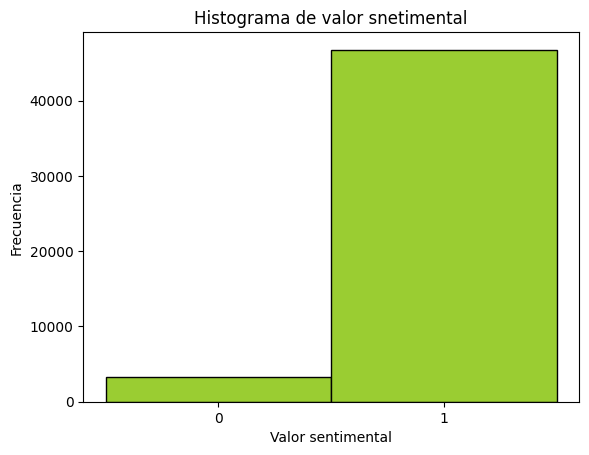

In [97]:
import matplotlib.pyplot as plt

plt.hist(data_books_df["rating"], bins=[0.5,1.5,2.5,3.5,4.5,5.5], edgecolor="black", color="yellowgreen", density=True)
plt.xlabel("Rating")
plt.xticks([1,2,3,4,5])
plt.ylabel("Frecuencia relativa")
plt.title("Histograma de ratings")
plt.show()

import matplotlib.pyplot as plt

plt.hist(data_books_df["sentiment"], bins=[-0.5,0.5,1.5], edgecolor="black", color="yellowgreen", density=False)
plt.xlabel("Valor sentimental")
plt.xticks([0,1])
plt.ylabel("Frecuencia")
plt.title("Histograma de valor snetimental")
plt.show()

Mas de un 60% de las reviews son "altamente positivas" con una clasificacionde 5 estrellas mientras que menos de un 10% representan las críticas, en general, negativas.
Por tanto, como es obvio, haremos esta selección de datos, cogiendo 5000 muestras balanceadas, es decir, 2500 muestras de cada caso.

In [44]:
# Aunque se sabe queremos 2500 muestras por clase, se hace de forma correcta, por si se cambiase el número de muestras:

n_total = 5000
n_per_class = n_total//2

casos_neg =data_books_df[data_books_df["sentiment"]==0]
caos_pos= data_books_df[data_books_df["sentiment"]==1]

print(casos_neg.shape) # en los primeros intentos cuando solo se habia cogido 20000 muestras inciales no se llegaba a tener 2500 reviews negativas

data_books_balanceado = pd.concat([casos_neg.sample(n=n_per_class, random_state= 5), caos_pos.sample(n=n_per_class, random_state=5)]).sample(frac=1, random_state=5).reset_index(drop=True) # una vez preseleccionada barajadas las reviews positivas y negativas,se baraja de nuevo

(3220, 3)


In [45]:
print(data_books_balanceado["sentiment"].value_counts())
data_books_balanceado.head()

sentiment
0    2500
1    2500
Name: count, dtype: int64


,rating,text,sentiment
0,2.0,"The main character, Diane, was hard to identif...",0
1,2.0,Several pages had pictures cut out by scissors...,0
2,5.0,I spent $40 on the audio book which makes it t...,1
3,5.0,Wow! This is one of the very best books I have...,1
4,2.0,I have to say when I first bought this book I ...,0


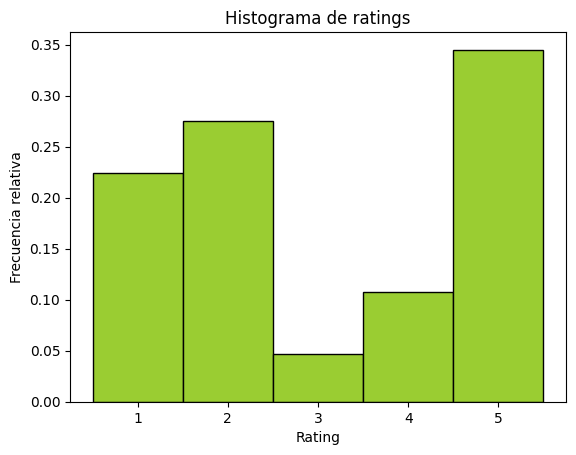

In [96]:
# se ve que las clases sentimientos estan equilibradas, vamos a ver como ha quedado el rating:

plt.hist(data_books_balanceado["rating"], bins=[0.5,1.5,2.5,3.5,4.5,5.5], edgecolor="black", color="yellowgreen", density=True)
plt.xlabel("Rating")
plt.xticks([1,2,3,4,5])
plt.ylabel("Frecuencia relativa")
plt.title("Histograma de ratings")
plt.show()

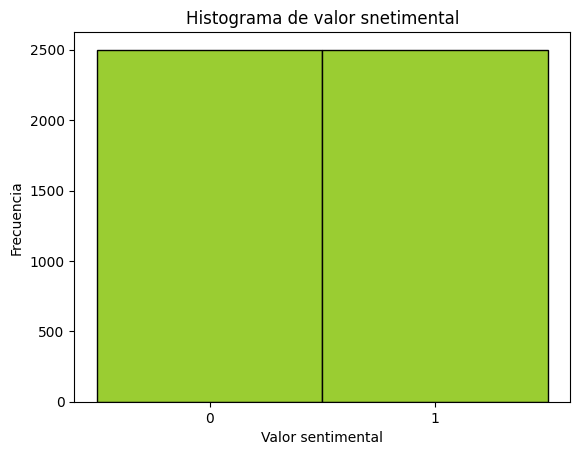

In [115]:
plt.hist(data_books_balanceado["sentiment"], bins=[-0.5,0.5,1.5], edgecolor="black", color="yellowgreen", density=False)
plt.xlabel("Valor sentimental")
plt.xticks([0,1])
plt.ylabel("Frecuencia")
plt.title("Histograma de valor snetimental")
plt.show()

Se ve que la clase 3 es la que metería más ruido ya que, si el sentimiento es positivo, suele ser prque el libro ha gustado verdaderamente consiguiendo hasta 5 estrellas. Por otro lado, en cuanto a las críticas negativas estas estçan equilibradas, probablemente porque a la gente le cuesta poner una estrella solo (como un "dislike"rotundo).

In [61]:
#Guardamos el data set para no tener que bajarnos el data set original de nuevo:

from google.colab import drive
import os
drive.mount('/content/drive')

! mkdir -p /content/drive/MyDrive/practica_NPL
! cd /content/drive/MyDrive/practica_NPL

path = "/content/drive/MyDrive/practica_NPL"

data_books_balanceado.to_csv(f'{path}/corpus_final.csv', index=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Una vez hecho la preparación básica del dataset, pasamos a su exploración sigueindo los pasos propuesto enn el enunciado de la práctica, también vistos en clase. Algunos de ellos como el de la distribución de las reviews por clases ya se han estudiado.

# 2.2 Cardinalidad del vocabulario:

Lo primero que se hace una vez tenemos el corpus con el que trabajar es explorar su contenido. Para ello, se estudia que tipo de palabras están contenidas y si es útil trabajr con todas ellas. Siguiendo un poco el esquema del noteboo 6 de clase:

In [78]:
textos = data_books_balanceado["text"].astype(str).str.lower()
palabras_total = []

for review in textos:
    frases_review = review.split(".")
    for frase in frases_review:
        palabras_frase = frase.split()
        palabras_total.extend(palabras_frase)


vocabulario = set(palabras_total)
print(vocabulario)


{'accuracy,', 'haggis', 'pillow,', 'itself)', 'acceptable,', '/>wow,', '(stuffed', 'hertasi', '1984', 'aroused', 'summer!', 'reordering', 'okinawan', 'mitre', 'nlq', 'developmental,', 'glasses,', 'wolff', '/>"jesus', "payton's", 'convenience', "khalid's", 'book/story', 'cherry', 'conspiracy,', 'sizzling', 'openly', 'universal', 'soccer', 'perfect', '16-ounce', '(scarlet', 'raccoon', 'limitations', 'charcater', '`body', 'strategies,', 'dreamer<br', 'ritual,', 'new?', 'm', 'thoughts-126<br', 'defeated', 'systems&quot;', 'atlanta,', 'dog<br', "'right'", 'bit)', 'grandchildren,', 'raymond', 'session—because', 'hires', 'heartaches', 'man,', 'hillbillies', 'exploration,', '/>dealing', 'pistol', 'witness,', 'allegiant', 'coccidiodmycosis', 'affectation', 'thoughts)', 'sleep?"<br', 'hurt!', 'factions,', 'finn),', 'roosevelt', '$25', 'spoken-word', 'in)', 'roam', 'wroth', "lackey's", 'plz', 'hunts', 'adoption,', 'coating', 'debauching', 'herbs]]<br', 'carnivirous', 'scanner', 'vendor,', '"smart

In [69]:
print("Número total de tokens:", len(palabras_total))
print("Cardinalidad del vocabulario:", len(vocabulario))

Número total de tokens: 631853
Cardinalidad del vocabulario: 49459


En un primer intento de tokenizar, se puede ver que existen tanto fallos ortográficos en las reviews como a la hora de dividir los tokens. Esto se irá arrglando a lo largo de la práctica con la normalización. De momento seguimos descubriendo cuales son las palabras o grupo de paabras más comunes, ya que hay una diferencia entre el número de tokes y la cardinalidad del vocabulario<:

In [72]:
from collections import Counter

Counter(palabras_total).most_common(20)

[('the', 30615),
 ('and', 18761),
 ('a', 16819),
 ('to', 16694),
 ('of', 14542),
 ('i', 11636),
 ('is', 10046),
 ('in', 8832),
 ('this', 8379),
 ('it', 7558),
 ('that', 7067),
 ('book', 6651),
 ('for', 6149),
 ('/><br', 5470),
 ('<br', 5121),
 ('was', 4908),
 ('with', 4858),
 ('you', 4119),
 ('are', 3977),
 ('but', 3868)]

Como se ven la mayoria se tratan de articulos y preposiciones que deberan ser eliminados. Esto se hará con el stopwords. De momento vamostambién cual es el conjutno  de palabras má comunes:

In [93]:

from nltk import ngrams
from nltk.probability import FreqDist

bigrams_ = list(ngrams(palabras_total, 2))
trigrams_ = list(ngrams(palabras_total, 3))
print("las parejas más comunes:\n", bigrams_[:10])
print("los tríos más comunes:\n", trigrams_[:10])

las parejas más comunes:
 [('the', 'main'), ('main', 'character,'), ('character,', 'diane,'), ('diane,', 'was'), ('was', 'hard'), ('hard', 'to'), ('to', 'identify'), ('identify', 'with'), ('with', 'the'), ('the', 'entire')]
los tríos más comunes:
 [('the', 'main', 'character,'), ('main', 'character,', 'diane,'), ('character,', 'diane,', 'was'), ('diane,', 'was', 'hard'), ('was', 'hard', 'to'), ('hard', 'to', 'identify'), ('to', 'identify', 'with'), ('identify', 'with', 'the'), ('with', 'the', 'entire'), ('the', 'entire', 'story')]


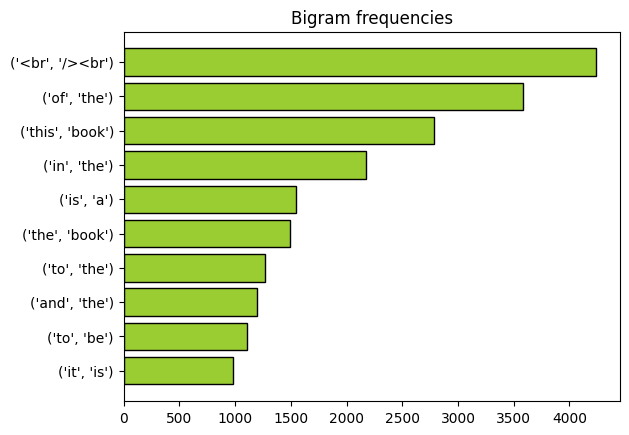

In [104]:
#Pra visualizar mejoras las parejas y trios,se hace un histograma como en clase:
bg_freq = FreqDist(bigrams_)
tg_freq = FreqDist(trigrams_)

bg_freq_most_common = bg_freq.most_common(10)
bgs_ = [str(bg[0]) for bg in bg_freq_most_common]
bgs_f_ = [bg[1] for bg in bg_freq_most_common]

tg_freq_most_common = tg_freq.most_common(10)
tgs_ = [str(tg[0]) for tg in tg_freq_most_common]
tgs_f_ = [tg[1] for tg in tg_freq_most_common]

bgs_f_, bgs_ = zip(*sorted(zip(bgs_f_, bgs_)))
tgs_f_, tgs_ = zip(*sorted(zip(tgs_f_, tgs_)))

plt.barh(bgs_, bgs_f_, color="yellowgreen", edgecolor="black")
plt.title('Bigram frequencies')
plt.show()

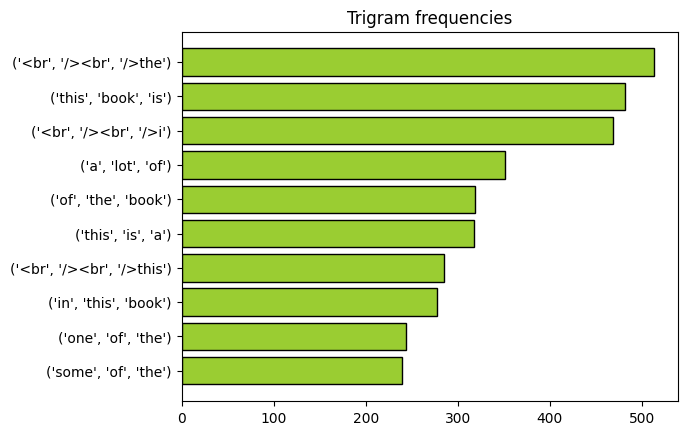

In [105]:
plt.barh(tgs_, tgs_f_, color="yellowgreen", edgecolor="black")
plt.title('Trigram frequencies')
plt.show()

Como se ha podido ver analizando las palabras más comunes, existen varios errores en nuestros tokens. El primero de todo es la falta de eliminación de las etiquetas de HTML. Por eso podemos ver que destacan "palabras" como "<br>"que no tienen ningún tipo de significado. También, como se ha mencionado anteriomente, es importante hacer un filtro con el STOPWORDS en inglés (idioma de las reviews) ya que las palabras con mayor  frecuencia son artículos o sujetos como it, los cuales no aportan información útil. En conclusión, tendreemos que tener todo esto en cuenta en el siguiente notebook al hacer el preprocesamiento de la data.

No obstante, seguimos con nuestro estudio exploratorio del dataset, mediante el uso de "word cloud". Gracias a este método,podremos indagar más enel contenido/palabras del dataset, pues hace su propia limpieza del texto por lo que no solemos ver preposiciones.

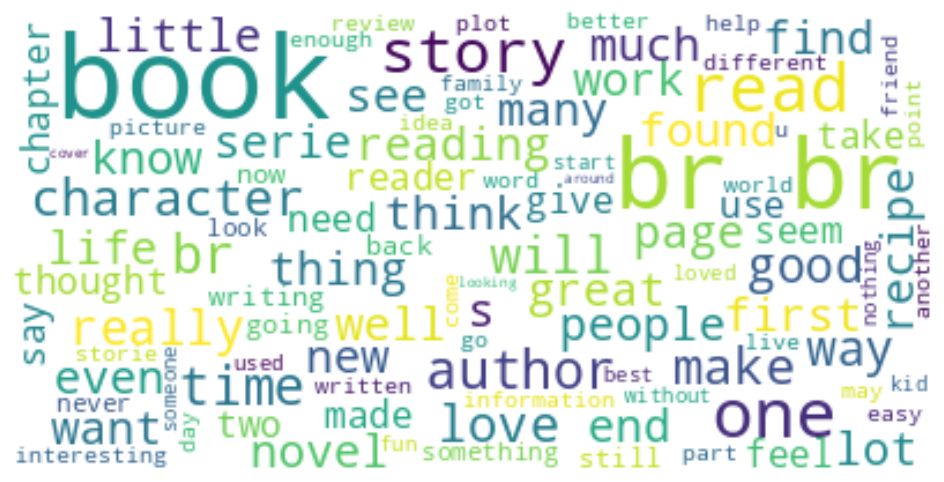

In [106]:
# SEGUN VISTO EN CLASE:
# una fomra más visual de ver que palabras se repiten mucho es mediante una cloud:
from wordcloud import WordCloud

def plot_word_cloud(text):
    wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white").generate(' '.join(text))
    plt.figure(figsize=(12,6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

#EL CASO GENERAL
plot_word_cloud(palabras_total)

Está claro que lo primero que destaca es la palabra "book" que como era de esperar en una reviews de libros apareciesen mucho. Podría haberse eliminado para la representación. De moemnto seguimos con la clasificación según sentimiento, a ver si podemos ver algo diferente:


In [88]:
# Conseguimos las palabras solo de cada una de las clases:
textos_positivos = data_books_balanceado[data_books_balanceado["sentiment"] == 1]["text"].astype(str).str.lower()
palabras_total_pos = []

for review in textos_positivos:
    frases_review = review.split(".")
    for frase in frases_review:
        palabras_frase = frase.split()
        palabras_total_pos.extend(palabras_frase)


vocabulario_pos = set(palabras_total_pos)
print(vocabulario_pos)

{'haggis', 'itself)', 'acceptable,', '/>wow,', '(stuffed', 'hertasi', '1984', 'summer!', 'okinawan', 'mitre', 'nlq', '/>"jesus', 'glasses,', 'wolff', "payton's", 'convenience', 'cherry', 'sizzling', 'openly', 'universal', 'soccer', 'perfect', '16-ounce', 'raccoon', 'limitations', '`body', 'strategies,', 'dreamer<br', 'ritual,', 'm', 'defeated', 'systems&quot;', 'dog<br', 'bit)', 'grandchildren,', 'raymond', 'hires', 'heartaches', 'man,', 'exploration,', '/>dealing', 'pistol', 'witness,', 'coccidiodmycosis', 'thoughts)', 'roosevelt', '$25', 'spoken-word', 'in)', 'roam', 'wroth', "lackey's", 'hunts', 'adoption,', 'coating', 'herbs]]<br', 'carnivirous', 'scanner', 'vendor,', 'chika’s', '"smart"', '/>spot', 'ojala', 'respectful', 'shared,', '(some', 'materials:', 'solveig', 'hospitality,', '[[asin:1596681144', 'yard', 'relevant:', 'uneducated', '168', 'endeavors', 'theo,', 'dictators,', 'teotwawki', 'executives', 'satisfaction!', 'stephen', '"pitfalls,', 'spans,', 'snowshoe', 'sources', 'o

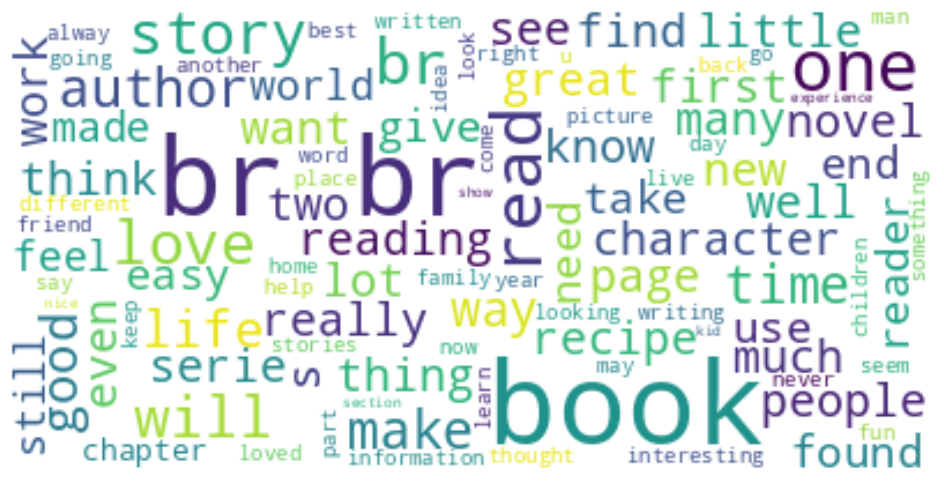

In [89]:
plot_word_cloud(palabras_total_pos)

In [107]:
textos_negativos = data_books_balanceado[data_books_balanceado["sentiment"] == 0]["text"].astype(str).str.lower()
palabras_total_neg = []

for review in textos_negativos:
    frases_review = review.split(".")
    for frase in frases_review:
        palabras_frase = frase.split()
        palabras_total_neg.extend(palabras_frase)


vocabulario_neg = set(palabras_total_neg)
print(vocabulario_pos)

{'haggis', 'itself)', 'acceptable,', '/>wow,', '(stuffed', 'hertasi', '1984', 'summer!', 'okinawan', 'mitre', 'nlq', '/>"jesus', 'glasses,', 'wolff', "payton's", 'convenience', 'cherry', 'sizzling', 'openly', 'universal', 'soccer', 'perfect', '16-ounce', 'raccoon', 'limitations', '`body', 'strategies,', 'dreamer<br', 'ritual,', 'm', 'defeated', 'systems&quot;', 'dog<br', 'bit)', 'grandchildren,', 'raymond', 'hires', 'heartaches', 'man,', 'exploration,', '/>dealing', 'pistol', 'witness,', 'coccidiodmycosis', 'thoughts)', 'roosevelt', '$25', 'spoken-word', 'in)', 'roam', 'wroth', "lackey's", 'hunts', 'adoption,', 'coating', 'herbs]]<br', 'carnivirous', 'scanner', 'vendor,', 'chika’s', '"smart"', '/>spot', 'ojala', 'respectful', 'shared,', '(some', 'materials:', 'solveig', 'hospitality,', '[[asin:1596681144', 'yard', 'relevant:', 'uneducated', '168', 'endeavors', 'theo,', 'dictators,', 'teotwawki', 'executives', 'satisfaction!', 'stephen', '"pitfalls,', 'spans,', 'snowshoe', 'sources', 'o

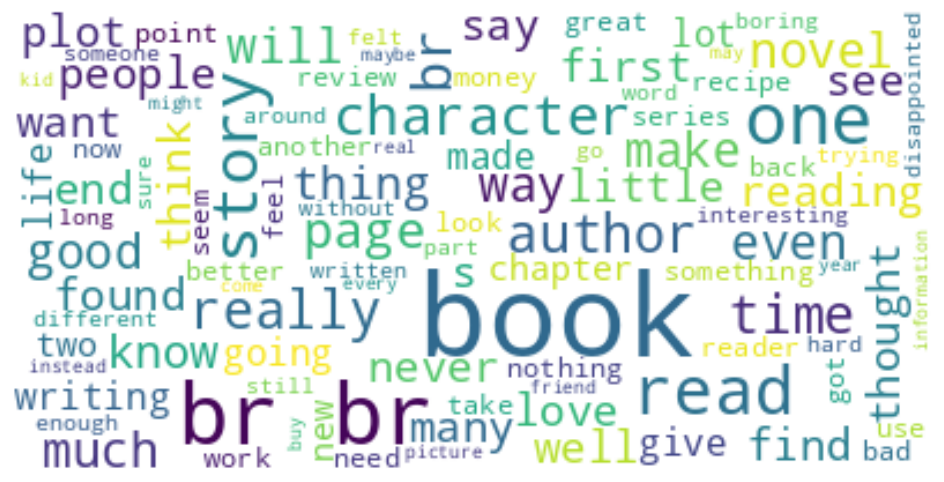

In [108]:
plot_word_cloud(palabras_total_neg)

Esta claro que existen ciertas similitudes y diferencias entre las nuebes de palabras de ambos sentmientos. Por un lado, como la nube general, se destacan las palabras "book","read" o "page" como era de esperar tartandose de libros. Esto es un recordatorio de que es importante a la hora de pasar de texto a un vector numerico para entrenar el modelo de predicción, que esta trasnformación no se base en simple frecuencia (como un one-hot o count vectoriser), pues no lleva a información útil la simple palabra libro. Es por ello que, posteriormente, se utilizará o un TF-IDF o un wordembedding como el word2vec.

Por otro lado, si nos fijamos en las palabras diferentes que destacan en cada nube de sentimiento, vemos que en la positiva se destacan palabras como "great", "love", "enjoy", "best", "character" que indican que se valora el contenido narativo asi omo que existe un valoración emocioanl positiva. En cambio, en la nube de las valoraciones con sentimiento negativo observamos palabras como "never", "disappointed", "boring" o incluso "feel", "thougth" que pueden venir de frases como ·yo pensaba que... pero...", es decir, haciendo una evaluación subjetiva negativa sobre el libro.

Por último, para terminar este primer notebook de visualiación de nuestro dataset, se pedía que se hiciese una visualización sobre un word embedding en 2 dimensiones de unas 4 palabras. Sin embargo, dado que para hacer un buena transformación de texto a vectores se debería tener un corpus trabajado y limpio, se ha decidido hacer esto en el siguiente notebook tras hacer el preprocesamiento del dataset.

# Conclusiones:

Como se ha ido comentando a lo largo del notebook, hemos podido visualizar los siguientes errores a etner en cuenta en el preprocesamiento que se hará a continuación:
- Se necesita eliminar las STOPWORDS, las cuales se deben actualizar con palabras eliminando tal vez las negaciones como "never" pues obviar información util sobre el sentimiento
- Eliminación de html
- Podemos comprobar si cumple la ley de Zipf en nuestro corpus

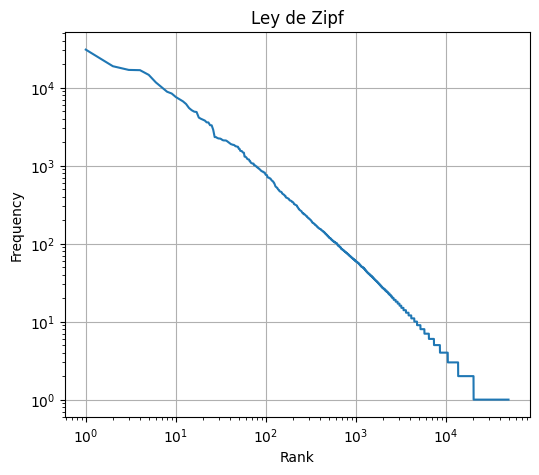

In [114]:
import numpy as np

#COMO VISTO EN CLASE:

palabras_total_freq = Counter(palabras_total)
frecuencias = {k: v for k, v in sorted(palabras_total_freq.items(), key=lambda item: item[1], reverse=True)}
ranks = list()
freqs = list()

for rank, word in enumerate(frecuencias):
    ranks.append(rank+1)
    freqs.append(frecuencias[word])

plt.figure(figsize=(6,5))
plt.loglog(ranks, freqs)
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Ley de Zipf")
plt.grid(True)
plt.show()

Queda demostrada la ley de Zipf, que demuestra la distribución natural de frecuencias léxica. Es por ello, que esta se debe demostarr ahora, con el corpus crudo y no tras el preprocesado.